In [148]:

import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [149]:
df= pd.read_csv('dataset.csv')
df.head()

,content,score
0,nice app,5
1,very nice app,4
2,free,5
3,WhatsApp is most happy platform is a bast app ...,5
4,so cure wat whatsapp,5


In [150]:
df = df[['content', 'score']].dropna().copy()
df = df[df['score'] != 3].copy()

In [151]:
def label(score):
    if score >= 4:
        return 1
    else:
        return 0

df['label'] = df['score'].apply(label)

In [152]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['text'] = df['content'].apply(clean_text)
df.head()

,content,score,label,text
0,nice app,5,1,nice app
1,very nice app,4,1,very nice app
2,free,5,1,free
3,WhatsApp is most happy platform is a bast app ...,5,1,whatsapp is most happy platform is a bast app ...
4,so cure wat whatsapp,5,1,so cure wat whatsapp


In [153]:
df = df[['text', 'label']].dropna().copy()

In [154]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['text', 'label'], dtype='object')


In [155]:
df_clean= df.copy()
df_clean['text_clean'] = df_clean['text'].apply(clean_text)

df_clean.head()

,text,label,text_clean
0,nice app,1,nice app
1,very nice app,1,very nice app
2,free,1,free
3,whatsapp is most happy platform is a bast app ...,1,whatsapp is most happy platform is a bast app ...
4,so cure wat whatsapp,1,so cure wat whatsapp


In [156]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
all_stopwords = set(stopwords.words('english'))
all_stopwords.update(['yeah', 'and', 'its', 'or', 'idk', 'ngl', 'lmao', 'lol', 'hihihi', 'pls', 'idc', 'wa', 'fuck', 'salary', 'dmn', 'easi', 'happi', 'heppy', 'wtf', 'wth', 'cmiiw', 'ty', 'gud'])
df_clean['text_StopWord'] = df_clean['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (all_stopwords)]))
df_clean.head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,label,text_clean,text_StopWord
0,nice app,1,nice app,nice app
1,very nice app,1,very nice app,nice app
2,free,1,free,free
3,whatsapp is most happy platform is a bast app ...,1,whatsapp is most happy platform is a bast app ...,whatsapp happy platform bast app mom dad long ...
4,so cure wat whatsapp,1,so cure wat whatsapp,cure wat whatsapp
5,self chat pin bug even after pinning multiple ...,0,self chat pin bug even after pinning multiple ...,self chat pin bug even pinning multiple times ...
6,tolong adain auto block no spam,1,tolong adain auto block no spam,tolong adain auto block spam
7,good,1,good,good
8,good,1,good,good
9,not nice,0,not nice,nice


In [157]:
from nltk.tokenize import word_tokenize
df_clean['text_tokens'] = df_clean['text_StopWord'].apply(lambda x: word_tokenize(x))
df_clean.head()

,text,label,text_clean,text_StopWord,text_tokens
0,nice app,1,nice app,nice app,"[nice, app]"
1,very nice app,1,very nice app,nice app,"[nice, app]"
2,free,1,free,free,[free]
3,whatsapp is most happy platform is a bast app ...,1,whatsapp is most happy platform is a bast app ...,whatsapp happy platform bast app mom dad long ...,"[whatsapp, happy, platform, bast, app, mom, da..."
4,so cure wat whatsapp,1,so cure wat whatsapp,cure wat whatsapp,"[cure, wat, whatsapp]"


In [158]:
from nltk.stem import PorterStemmer
ps= PorterStemmer()
df_clean['text_stemmed']= df_clean['text_tokens'].apply(
    lambda tokens: [ps.stem(word) for word in tokens])

df_clean.head(10)

,text,label,text_clean,text_StopWord,text_tokens,text_stemmed
0,nice app,1,nice app,nice app,"[nice, app]","[nice, app]"
1,very nice app,1,very nice app,nice app,"[nice, app]","[nice, app]"
2,free,1,free,free,[free],[free]
3,whatsapp is most happy platform is a bast app ...,1,whatsapp is most happy platform is a bast app ...,whatsapp happy platform bast app mom dad long ...,"[whatsapp, happy, platform, bast, app, mom, da...","[whatsapp, happi, platform, bast, app, mom, da..."
4,so cure wat whatsapp,1,so cure wat whatsapp,cure wat whatsapp,"[cure, wat, whatsapp]","[cure, wat, whatsapp]"
5,self chat pin bug even after pinning multiple ...,0,self chat pin bug even after pinning multiple ...,self chat pin bug even pinning multiple times ...,"[self, chat, pin, bug, even, pinning, multiple...","[self, chat, pin, bug, even, pin, multipl, tim..."
6,tolong adain auto block no spam,1,tolong adain auto block no spam,tolong adain auto block spam,"[tolong, adain, auto, block, spam]","[tolong, adain, auto, block, spam]"
7,good,1,good,good,[good],[good]
8,good,1,good,good,[good],[good]
9,not nice,0,not nice,nice,[nice],[nice]


In [159]:
X=df_clean['text_stemmed']
y= df_clean['label']

In [160]:
labelcounts= df['label'].value_counts()
for label, count in labelcounts.items():
    print(f"Label {label}: {count} rows")
print({df.shape})

Label 1: 7536 rows
Label 0: 1988 rows
{(9524, 2)}


In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

pd.pandas.set_option('display.max_columns', None)

Number of null in label: 0
Number of null in text: 0


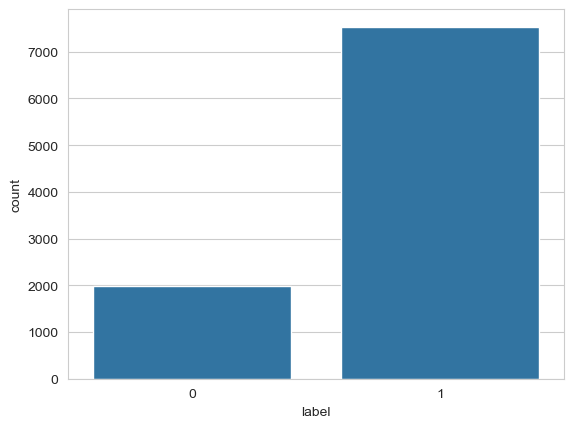

In [162]:
print(f"Number of null in label: {df['label'].isnull().sum()}")
print(f"Number of null in text: {df['text'].isnull().sum()}")
sns.countplot(x='label', data=df);

In [163]:
X_train, X_test,  y_train, y_test= train_test_split(df_clean['text_stemmed'], df_clean['label'], 
                                                   test_size= 0.30,
                                                   random_state=42,
                                                   stratify= y)

In [164]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(6666,)
(6666,)
(2858,)
(2858,)


In [165]:
positive = df[df['label'] == 1]
negative = df[df['label'] == 0]

positive_sample = positive.sample(n=len(negative), random_state=42)

df_balanced = pd.concat([positive_sample, negative])
df_balanced = df_balanced.sample(frac=1, random_state=42)

In [166]:
X_train = X_train.apply(lambda x: " ".join(x))
X_test = X_test.apply(lambda x: " ".join(x))

In [167]:
tfidf= TfidfVectorizer()
tfidf_train= tfidf.fit_transform(X_train)

tfidf_test= tfidf.transform(X_test)
print(tfidf.get_feature_names_out())

tfidf_mat= tfidf_train.toarray()

['aa' 'aaaaaaa' 'aacha' ... 'zx' 'zxa' 'zz']


In [168]:
tfidf_mat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6666, 4406))

In [169]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words= 'english', 
    min_df= 2,
    max_df=0.9
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=2000
)

word_tfidf=TfidfVectorizer(
    max_features= 8000,
    ngram_range=(1,2)
)

In [170]:

from scipy.sparse import hstack

X_train_word = word_tfidf.fit_transform(X_train)
X_test_word = word_tfidf.transform(X_test)

X_train_char = char_tfidf.fit_transform(X_train)
X_test_char = char_tfidf.transform(X_test)

X_train_combined = hstack([X_train_word, X_train_char])
X_test_combined = hstack([X_test_word, X_test_char])

In [171]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearSVC(C=0.1),
    tfidf_train,
    y_train,
    cv=5
)

print(scores)
print("Mean:", scores.mean())

[0.83808096 0.81470368 0.81995499 0.83945986 0.82595649]
Mean: 0.8276311956549858


In [172]:
for c in [0.09, 1, 1.2]:
    model = LinearSVC(C=c, max_iter= 800)
    model.fit(tfidf_train, y_train)
    y_pred = model.predict(tfidf_test)
    print(c, accuracy_score(y_test, y_pred))

0.09 0.8414975507347796
1 0.8488453463960812
1.2 0.8477956613016095


In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'].astype(str),
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [174]:
tokenizer = Tokenizer(num_words=8000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [175]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [176]:
maxlen = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')

In [177]:
from tensorflow.keras.layers import Bidirectional, LSTM

model = Sequential([
    Embedding(8000, 128, input_length=100),

    Bidirectional(LSTM(64, return_sequences=False)),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [178]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [179]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=1,
    restore_best_weights=True
)

In [180]:
model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=35,
    validation_split=0.2,
    callbacks= [early_stop]
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.8092 - loss: 0.4404 - val_accuracy: 0.8465 - val_loss: 0.3803
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.8689 - loss: 0.3380 - val_accuracy: 0.8484 - val_loss: 0.3683
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 110ms/step - accuracy: 0.9027 - loss: 0.2721 - val_accuracy: 0.8465 - val_loss: 0.3889


In [181]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8541 - loss: 0.3694
Test Accuracy: 0.8540682196617126
